In [7]:
import os
import warnings
from transformers import logging

warnings.filterwarnings("ignore")
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"
os.environ["TRANSFORMERS_VERBOSITY"] = "error"
logging.set_verbosity_error()

In [ ]:
# loading dataset
from datasets import load_dataset

# data processing
import pandas as pd
import numpy as np
import math

# charts
import matplotlib.pyplot as plt
import seaborn as sns

# Pretreained HerBERT
from transformers import pipeline
import torch
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

import transformers
transformers.utils.logging.set_verbosity_error()

import os
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

In [9]:
dataset = load_dataset ("allegro/klej-polemo2-in", split ="test")

df = pd.DataFrame(dataset)

label_mapping = {
    '__label__meta_minus_m': 'Negative',
    '__label__meta_plus_m': 'Positive',
    '__label__meta_zero': 'Neutral',
}

df['text_length'] = df['sentence'].apply(len)

# remove ambigous target
df = df[df['target'] != '__label__meta_amb']

# map targets to more readable names
df['target'] = df['target'].map(label_mapping)

In [10]:
reviews_texts = df['sentence'].tolist()

model_label_mapping = {
    'neutral': 'Neutral',
    'negative': 'Negative',
    'positive': 'Positive'
}

In [11]:


models_list = [
    "Voicelab/herbert-base-cased-sentiment",
    "eevvgg/bert-polish-sentiment-politics",
    # "nie3e/sentiment-polish-gpt2-small",
    # "nie3e/sentiment-polish-gpt2-large",
    # "rafal-adamczyk/herbert-polish-sentiment-lora",
    "KDhaoran/TM_bert-polish-sentiment-politics",
    "9ulia/herbert-polish-sentiment-9ulia"
]

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 8379.77it/s]


Voicelab/herbert-base-cased-sentiment
{'label': 'positive', 'score': 0.9934391379356384}
{'label': 'negative', 'score': 0.9762535691261292}
{'label': 'neutral', 'score': 0.727185845375061}
{'label': 'positive', 'score': 0.5185975432395935}
{'label': 'positive', 'score': 0.9989897608757019}
{'label': 'positive', 'score': 0.9992570281028748}
{'label': 'positive', 'score': 0.9985604882240295}

Positive
Negative
Neutral
Positive
Positive
Positive
Positive


===== TEMP Voicelab/herbert-base-cased-sentiment =====

              precision    recall  f1-score   support

    Negative       0.97      0.85      0.91       300
     Neutral       0.34      0.14      0.20       117
    Positive       0.64      0.98      0.78       197

    accuracy                           0.76       614
   macro avg       0.65      0.66      0.63       614
weighted avg       0.74      0.76      0.73       614



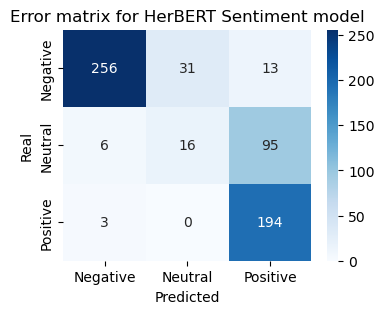

ValueError: Could not load model eevvgg/bert-polish-sentiment-politics with any of the following classes: (<class 'transformers.models.auto.modeling_auto.AutoModelForSequenceClassification'>, <class 'transformers.models.bert.modeling_bert.BertForSequenceClassification'>). See the original errors:

while loading with AutoModelForSequenceClassification, an error is thrown:
Traceback (most recent call last):
  File "s:\dev\apps\Miniconda\envs\ai_list5\Lib\site-packages\transformers\pipelines\base.py", line 232, in load_model
    model = model_class.from_pretrained(model, **kwargs)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "s:\dev\apps\Miniconda\envs\ai_list5\Lib\site-packages\transformers\models\auto\auto_factory.py", line 374, in from_pretrained
    return model_class.from_pretrained(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "s:\dev\apps\Miniconda\envs\ai_list5\Lib\site-packages\transformers\modeling_utils.py", line 4137, in from_pretrained
    loading_info, d

In [ ]:
f1_scores = []
accuracy_scores = []

for model in models_list:
    classifier = pipeline(
        "text-classification",
        model=model,
        device="cuda",
    )

    preds_raw = classifier(
        reviews_texts,
        batch_size=32,
        truncation=True,
        max_length=512,
        stride=64
    )

    print(model)
    print(preds_raw[0])
    print(preds_raw[1])
    print(preds_raw[2])
    print(preds_raw[3])
    print(preds_raw[4])
    print(preds_raw[5])
    print(preds_raw[6])
    print()

    preds_labels_raw = [pred['label'].lower() for pred in preds_raw]

    preds = [model_label_mapping.get(lbl, lbl) for lbl in preds_labels_raw]

    print(preds[0])
    print(preds[1])
    print(preds[2])
    print(preds[3])
    print(preds[4])
    print(preds[5])
    print(preds[6])
    print()
    
    print(f"\n===== TEMP {model} =====\n")
    print(classification_report(df['target'], preds))

    plt.figure(figsize=(4, 3))
    cm = confusion_matrix(df['target'], preds, labels=['Negative', 'Neutral', 'Positive'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Neutral', 'Positive'], yticklabels=['Negative', 'Neutral', 'Positive'])
    plt.ylabel('Real')
    plt.xlabel('Predicted')
    plt.title('Error matrix for HerBERT Sentiment model')
    plt.show()
    

    accuracy_scores.append(accuracy_score(df['target'], preds))
    f1_scores.append(f1_score(df['target'], preds, average='weighted'))
    
    print()


In [ ]:
x = np.arange(len(models_list))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

rects1 = ax.bar(x - width/2, accuracy_scores, width, label='Accuracy', color='#1f77b4')
rects2 = ax.bar(x + width/2, f1_scores, width, label='F1-Score (Weighted)', color='#ff7f0e')

ax.set_ylabel('Scores', fontsize=12, fontweight='bold', labelpad=10)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(models_list, rotation=15, ha='right', fontsize=10)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=11, loc='lower left', frameon=True)

for rect in rects1 + rects2:
    height = rect.get_height()
    ax.annotate(f'{height:.3f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=9, fontweight='semibold')

plt.tight_layout()